# Vector GBT experiment

This notebook illustrates the algorithm from previous notebooks applied to a simple problem: find the optimal split threshold and leaf values of a first boosting iteration on a subsample of the CovType dataset, pre-selecting the feature/column on which the split will be made, and compares this against the approach from XGBoost with a diagonal upper bound on the Hessian.

# A look at the dataset

In [1]:
import numpy as np
from sklearn.datasets import fetch_covtype
X, y = fetch_covtype(return_X_y=True)
X = X[:5_000]
y = y[:5_000]

y = (y - 1).astype(int)
k = y.max() + 1
n = y.shape[0]

Y_wide = np.zeros((y.shape[0], y.max() + 1))
Y_wide[np.arange(n), y] = 1.
Y_wide.mean(axis=0)

array([0.1114, 0.1896, 0.1286, 0.2498, 0.189 , 0.0958, 0.0358])

# Multinomial logistic function, gradient and Hessian

These assume that the `X` supplied is a matrix of shape $n \times (k-1)$ if using a reference class, or $n \times k$ otherwise, with the current scores assigned to each observation.

In [2]:
from scipy.special import softmax

def mnl_function(X, Y_wide, ref_class: bool = True):
    if ref_class:
        # last class is reference class, constrained to zero
        X = np.c_[X, np.zeros((X.shape[0], 1))]
    p = softmax(X, axis=1)
    return -np.sum(
        Y_wide*np.log(p) + (1-Y_wide)*np.log(1-p)
    )
def mnl_grad(X, Y_wide):
    k1 = X.shape[1]
    X = np.c_[X, np.zeros((X.shape[0], 1))]
    p = softmax(X, axis=1)
    return (Y_wide - p)[:, :k1]
def mnl_hess(X, Y_wide):
    k1 = X.shape[1]
    n = Y_wide.shape[0]
    k = Y_wide.shape[1]
    X = np.c_[X, np.zeros((n, 1))]
    p = softmax(X, axis=1)
    H = np.empty((n, k, k))
    for row in range(n):
        H[row] = np.diag(p[row]) - np.outer(p[row], p[row])
    return H[:, :k1, :k1]

# Baseline: intercepts-only

As a starting point for boosting iterations, one might want to initialize the scores to intercepts that minimize the objective function. These have an easy closed form. From this, one can then evaluate the multinomial log-loss function to see how it decreases with further boosting iterations.

In [3]:
base_sol = np.log(Y_wide.mean(axis=0))
base_sol -= base_sol[-1]
base_sol = base_sol[:-1]
base_sol = np.tile(base_sol, n).reshape((n, k-1))
mnl_function(base_sol, Y_wide, ref_class=True)

np.float64(13678.952061597256)

# XGBoost Solution

Producing a single split with XGBoost, adjusting the parameters to reflect the desired scenario - just add optimal leafs from this simple split to the intercepts:

In [4]:
import xgboost as xgb

model = xgb.train(
    dtrain=xgb.QuantileDMatrix(X[:, [0]], y, max_bin=10_000),
    num_boost_round=1,
    params={
        "objective": "multi:softprob",
        "num_class": k,
        "multi_strategy": "multi_output_tree",
        "max_depth": 1,
        "learning_rate": 1.0,
        "lambda": 0.,
        "max_bin": 10_000,
    },
)

pred_xgb = model.predict(xgb.DMatrix(X[:, [0]]), output_margin=True)
mnl_function(
    pred_xgb,
    Y_wide,
    ref_class=False,
)

np.float64(11255.603491807356)

As can be seen, the objective function decreased after this split - goal is now to compare how much this reduction would fare against what would be obtained from a similar single iteration based on the true Hessians.

Along with the log-loss, it is also interesting to see what split threshold it picked:

In [5]:
import polars as pl
# Workaround to determine where was the split point

leaf_index = model.predict(xgb.DMatrix(X[:, [0]]), pred_leaf=True)
df_stats = (
    pl.DataFrame({
        "col0": X[:, 0],
        "leaf": leaf_index - 1,
    })
    .group_by("leaf")
    .agg(
        pl.col("col0").min().alias("minval"),
        pl.col("col0").max().alias("maxval"),
    )
    .sort("leaf")
)
df_stats

leaf,minval,maxval
f32,f64,f64
0.0,1863.0,2475.0
1.0,2486.0,3442.0


In [6]:
xgb_split_point = df_stats["maxval"][0] + 0.5*(df_stats["minval"][1] - df_stats["maxval"][0])
xgb_split_point

2480.5

# True Hessian Solution

Same logic - single split and optimal leaf calculation - but now done manually through the algorithm that uses the true Hessian, starting from the optimal intercepts calculated earlier:

In [7]:
G = mnl_grad(base_sol, Y_wide)
H = mnl_hess(base_sol, Y_wide)

A = H.sum(axis=0)
b = G.sum(axis=0)
A_left = np.zeros_like(A)
b_left = np.zeros_like(b)
qs_best = np.inf

thr_history = list()

sorted_order_col0 = np.argsort(X[:, 0])
for ind in range(n-1):
    row = sorted_order_col0[ind]
    row_next = sorted_order_col0[ind+1]
    A_left += H[row]
    b_left += G[row]

    # if next value is the same, cannot make a split here
    if X[row, 0] == X[row_next, 0]:
        continue
    threshold = X[row, 0] + 0.5 * (X[row_next, 0] - X[row, 0])

    A_right = A - A_left
    b_right = b - b_left
    x_left = np.linalg.solve(A_left, b_left)
    x_right = np.linalg.solve(A_right, b_right)

    qs_left = 0.5 * (x_left @ A_left @ x_left) - x_left @ b_left
    qs_right = 0.5 * (x_right @ A_right @ x_right) - x_right @ b_right
    qs_this = qs_left + qs_right
    thr_history.append({"thr": threshold, "qs": qs_this})

    if qs_this < qs_best:
        qs_best = qs_this
        thr_best = threshold
        x_left_best = x_left
        x_right_best = x_right
thr_best

np.float64(2480.5)

The threshold it found in this case is the same, but the leaf values are different, as would be the objective function under these values:

In [8]:
assign_left_branch = X[:, 0] <= thr_best
new_scores = base_sol.copy()
new_scores[assign_left_branch, :] += x_left_best
new_scores[~assign_left_branch, :] += x_right_best

mnl_function(
    new_scores,
    Y_wide,
    ref_class=True,
)

np.float64(10620.083698450968)

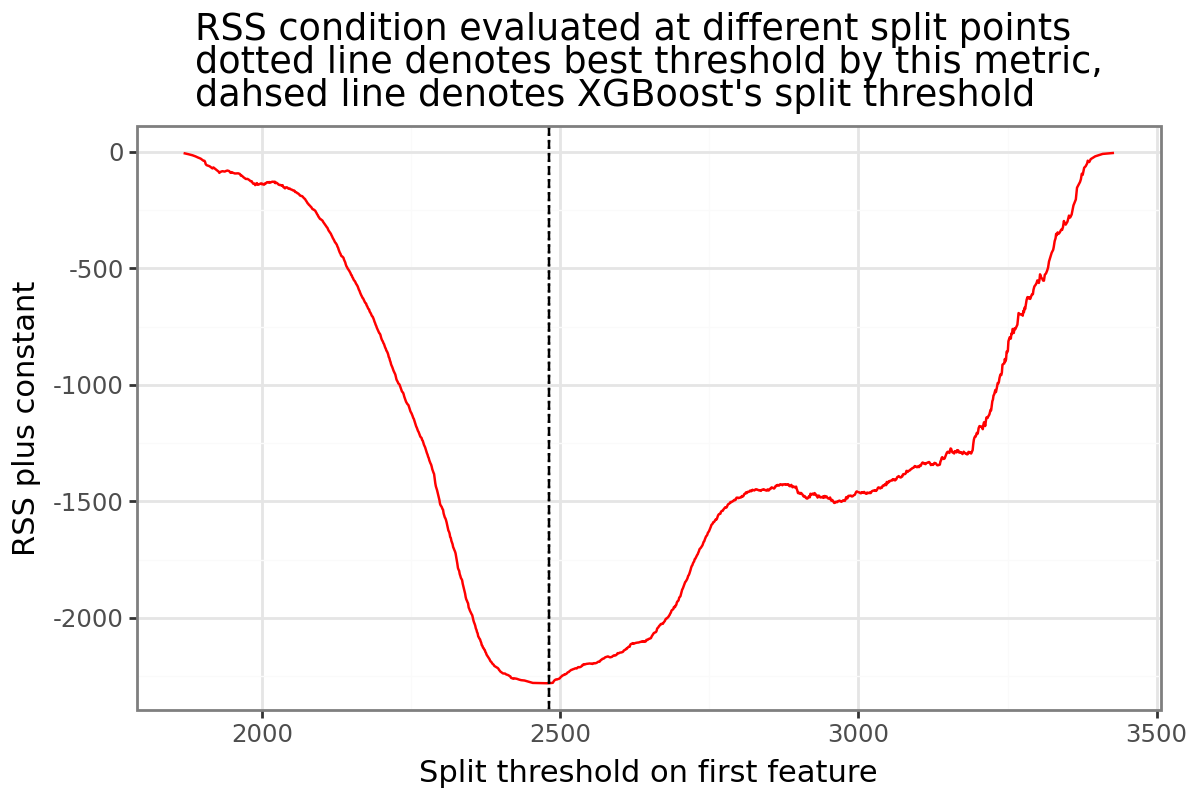

In [9]:
import plotnine as p9
(
    p9.ggplot(pl.DataFrame(thr_history), p9.aes(x="thr", y="qs"))
    + p9.theme_bw()
    + p9.geom_line(color="red")
    + p9.geom_vline(xintercept=thr_best, linetype="dotted")
    + p9.geom_vline(xintercept=xgb_split_point, linetype="dashed")
    + p9.xlab("Split threshold on first feature")
    + p9.ylab("RSS plus constant")
    + p9.ggtitle(
        "RSS condition evaluated at different split points"
        "\ndotted line denotes best threshold by this metric,"
        "\ndahsed line denotes XGBoost's split threshold"
    )
    + p9.theme(figure_size=(6,4))
).show()

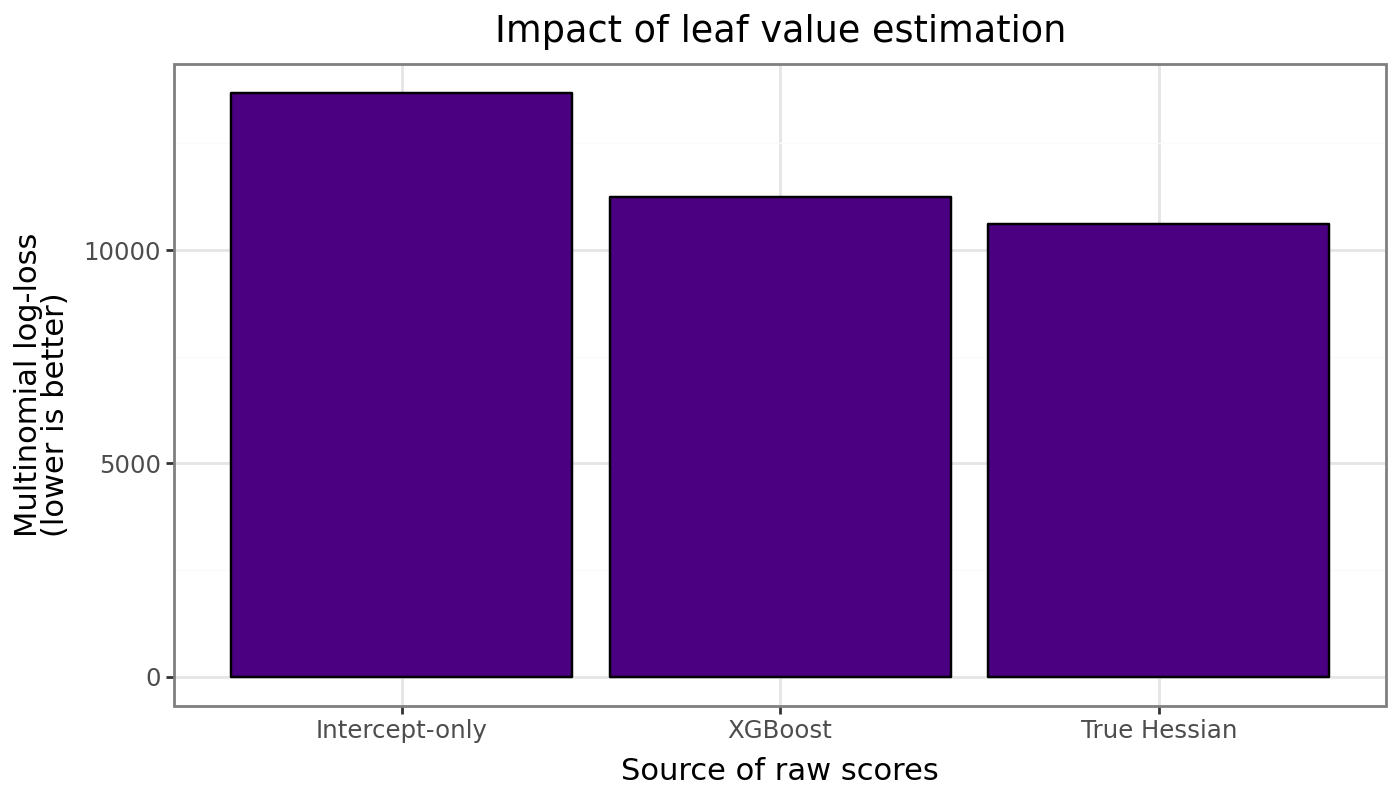

In [10]:
(
    p9.ggplot(
        pl.DataFrame({
            "Scores": ["Intercept-only", "XGBoost", "True Hessian"],
            "Log-loss": [
                mnl_function(base_sol, Y_wide, ref_class=True),
                mnl_function(pred_xgb, Y_wide, ref_class=False),
                mnl_function(new_scores, Y_wide, ref_class=True),
            ]
        }).with_columns(pl.col("Scores").cast(pl.Categorical)),
        p9.aes(x="Scores", y="Log-loss")
    )
    + p9.theme_bw()
    + p9.geom_bar(stat="identity", color="black", fill="indigo")
    + p9.ylab("Multinomial log-loss\n(lower is better)")
    + p9.xlab("Source of raw scores")
    + p9.ggtitle(
        "Impact of leaf value estimation"
    )
    + p9.theme(figure_size=(7,4))
)